In [1]:
using ITensors, ITensorMPS
using ITensorExpMPO
using ITensors: Algorithm
using Plots
using Plots.PlotMeasures
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)


using LsqFit

In [2]:
N = 100
sites = siteinds("S=1/2", N)
lambda = 1.0 # Critical point

1.0

Hamiltonian of the Alcaraz Model given by:

$$H = -\sum_i \left( \sigma_i^z \sigma_{i+1}^z + \lambda \sigma_i^x \mathbf{+} p (\sigma_i^z \sigma_{i+2}^z + \lambda \sigma_i^x \sigma_{i+1}^x \right))$$

In [18]:
function build_alcaraz_H(sites, lambda, p)
    N = length(sites)
    os = OpSum()
    
    # Transverse field applies to all sites (on-site term)
    for i in 1:N
        os += -lambda, "X", i
    end
    
    # Nearest neighbor terms
    for i in 1:(N-1)
        os += -1.0, "Z", i, "Z", i+1
        os += -p * lambda, "X", i, "X", i+1
    end
    
    # Next-nearest neighbor terms
    for i in 1:(N-2)
        os += -p, "Z", i, "Z", i+2
    end
    
    return MPO(os, sites)
end

build_alcaraz_H (generic function with 1 method)

In [4]:
function compute_vn_entropy(psi::MPS)
    N = length(psi)
    entropies = Float64[]
    
    # We measure cuts from l=1 to N-1
    for b in 1:(N-1)
        orthogonalize!(psi, b)

        if b == 1
            _, S, _ = svd(psi[b], siteind(psi, b))
        else
            _, S, _ = svd(psi[b], (linkind(psi, b-1), siteind(psi, b)))
        end
        
        SvN = 0.0
        for n in 1:dim(S, 1)
            prob = S[n,n]^2
            if prob > 1e-12
                SvN -= prob * log(prob)
            end
        end
        push!(entropies, SvN)
    end
    return entropies
end

compute_vn_entropy (generic function with 1 method)

The finite-size scaling behavior for a periodic chain (with OBC) is given by 

$$S_{vN}(l, L-l) = \frac{c}{6} \ln\left(\frac{L}{\pi} \sin\left(\frac{l\pi}{L}\right)\right) + k$$

Estimated central charge for p=0.0 : c = 0.508
Estimated central charge for p=0.5 : c = 0.508
Estimated central charge for p=1.0 : c = 0.513
Estimated central charge for p=1.5 : c = 0.521
Estimated central charge for p=3.0 : c = 0.548
Estimated central charge for p=6.0 : c = 0.605
Estimated central charge for p=10.0 : c = 0.67
Estimated central charge for p=20.0 : c = 0.759


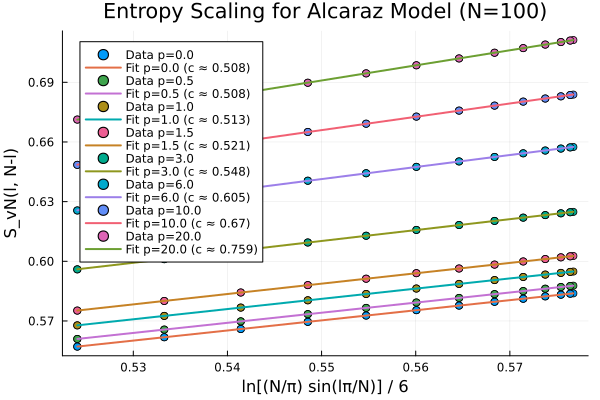

In [ ]:
sweeps = Sweeps(15) 
maxdim = (sweeps, 10, 20, 100, 200, 400)
cutoff = (sweeps, 1e-10)
noise = (sweeps, 1e-4, 1e-5, 1e-6, 0.0)

p_values = [0.0, 0.5, 1.0, 1.5, 3.0, 6.0, 10.0, 20.0]
N=100

results = Dict()

fig = plot(title="Entropy Scaling for Alcaraz Model (N=$N)",
           xlabel="ln[(N/π) sin(lπ/N)] / 6",
           ylabel="S_vN(l, N-l)",
           legend=:topleft,
           grid=true)

for p in p_values
    H = build_alcaraz_H(sites, lambda, p)
    
    psi0 = randomMPS(sites, 10)
    
    # Run DMRG
    energy, psi = dmrg(H, psi0; sweeps=sweeps, maxdim=maxdim, cutoff=cutoff, noise=noise, outputlevel=0)
    
    # Compute VN Entropy
    entropies = compute_vn_entropy(psi)

    # Only fit the even bonds in the middle half of the chain
    start_idx = div(N, 4)
    start_idx = iseven(start_idx) ? start_idx : start_idx + 1 
    end_idx = div(3 * N, 4)
    
    l_fit = start_idx:2:end_idx
    
    # Calculate the CFT scaling variable: x = ln[(L/pi) * sin(l*pi/L)] / 6 (for open boundary conditions)
    x_values = [log((N/pi) * sin(l * pi / N)) / 6.0 for l in l_fit]
    y_values = entropies[l_fit]
    
    # Model function for linear fit: S = c*x + k -> f(x, p) = p[1]*x + p[2]
    @. model(x, p) = p[1]*x + p[2]
    p0 = [1.0, 1.0] # Initial guess for [slope, intercept]

    fit = curve_fit(model, x_values, y_values, p0)
    c_est = fit.param[1] # slope
    
    results[p] = (x_values, y_values, c_est)
    println("Estimated central charge for p=$p : c = $(round(c_est, digits=3))")

    # Plotting
    scatter!(fig, x_values, y_values, label="Data p=$p", markersize=4)
    
    y_fit = model(x_values, fit.param)
    plot!(fig, x_values, y_fit, label="Fit p=$p (c ≈ $(round(c_est, digits=3)))", linewidth=2)
end

display(fig)

Now let us plot the slope (central charge $c$) value as a function of $p$ to find until which values of $p$ the system remains critical.

In [11]:
# DMRG params
nsweeps = 15
maxdims = [10, 20, 100, 200, 400]
cutoffs = [1e-10]
noises  = [1e-4, 1e-5, 1e-6, 0.0]

N=300
sites = siteinds("S=1/2", N)
lambda = 1.0 # Critical point
p_values = 0.0 : 0.2 : 2.0
estimated_c = Float64[]
actual_p = Float64[]

# Linear Fit Model defiend only once globally
model(x, params) = params[1] .* x .+ params[2]
p_guess = [1.0, 1.0]

@showprogress "Sweeping p values..." for p in p_values
    H = build_alcaraz_H(sites, lambda, p)

    # initialize random state for the very first step
    psi0 = randomMPS(sites, 10)
    
    energy, psi = dmrg(H, psi0; 
                       nsweeps=nsweeps, 
                       maxdim=maxdims, 
                       cutoff=cutoffs, 
                       noise=noises, 
                       outputlevel=0)
        
    # Compute VN Entropy
    entropies = compute_vn_entropy(psi)

    # Only fit the even bonds in the middle half of the chain
    start_idx = div(N, 4)
    start_idx = iseven(start_idx) ? start_idx : start_idx + 1 
    end_idx = div(3 * N, 4)
    
    l_fit = start_idx:2:end_idx
    
    # Calculate the CFT scaling variable
    x_values = [log((N/pi) * sin(l * pi / N)) / 6.0 for l in l_fit]
    y_values = entropies[l_fit]
    
    # Linear fit
    fit = curve_fit(model, x_values, y_values, p_guess)
    c_est = fit.param[1]
    println("Estimated central charge for p=$p : c = $(round(c_est, digits=3))")
    
    # Store the results
    push!(estimated_c, c_est)
    push!(actual_p, p)
end

Estimated central charge for p=0.0 : c = 0.502
Estimated central charge for p=0.2 : c = 0.502


Sweeping p values...  18%|█████▋                         |  ETA: 0:02:32

Estimated central charge for p=0.4 : c = 0.503


Sweeping p values...  27%|████████▌                      |  ETA: 0:02:35

Estimated central charge for p=0.6 : c = 0.503


...

Sweeping p values...  82%|█████████████████████████▍     |  ETA: 0:01:05

Estimated central charge for p=1.8 : c = 0.509


Sweeping p values...  91%|████████████████████████████▏  |  ETA: 0:00:34

Estimated central charge for p=2.0 : c = 0.51


Sweeping p values... 100%|███████████████████████████████| Time: 0:06:39


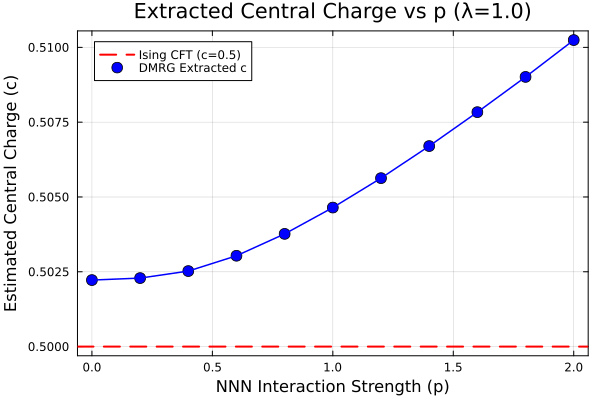

"/home/jmarquezol/Documents/masters/QuantumMaster/master_thesis/imgs/p_dependence.png"

In [14]:
# Plotting
fig_c = plot(title="Extracted Central Charge vs p (λ=$lambda)",
             xlabel="NNN Interaction Strength (p)",
             ylabel="Estimated Central Charge (c)",
            #  legend=:bottomleft,
             grid=true,
             framestyle=:box)

# theoretical reference line
hline!(fig_c, [0.5], label="Ising CFT (c=0.5)", color=:red, linestyle=:dash, linewidth=2)

scatter!(fig_c, actual_p, estimated_c, 
         label="DMRG Extracted c", 
         marker=:circle, 
         color=:blue, 
         markersize=6)
plot!(fig_c, actual_p, estimated_c, 
      label="",
      color=:blue, 
      linewidth=1.5)

display(fig_c)
savefig(fig_c, "./imgs/p_dependence.png")

Note that for $p=0$, $c$ is not exactly 0.5 due to finite-size effects (double check this)

---

According to Conformal Field Theory (CFT), the von Neumann entropy for an open chain of length $L$ cut at subsystem size $l$ is given by

$$S(l) = \frac{c}{6} \ln \left( \frac{L}{\pi} \sin\left(\frac{l\pi}{L}\right) \right) + k$$

The maximum entanglement is always exactly in the middle of the chain, where $l = L/2$. If we plug $L/2$ into the sine function, $\sin(\pi/2) = 1$. Then the formula simplifies to:

$$S(L/2) = \frac{c}{6} \ln(L) + k'$$

Let us run DMRG for different system sizes ($L$), extract the entropy strictly at the middle bond, and plot it against $\ln(L)$. We should get a perfectly straight line with a slope of $c/6$.

Progress: 100%|█████████████████████████████████████████| Time: 0:01:47


Estimated Central Charge (c): 0.511


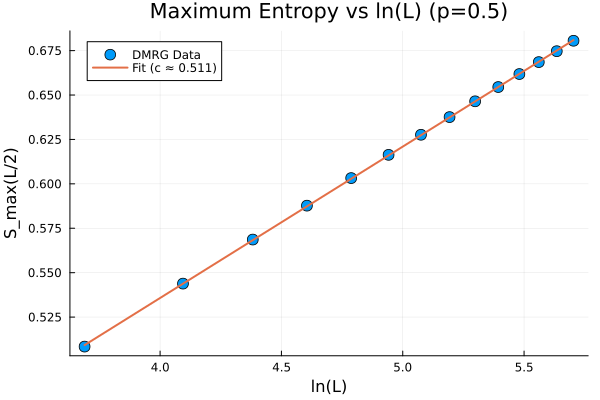

"/home/jmarquezol/Documents/masters/QuantumMaster/master_thesis/imgs/cft_L.png"

In [16]:
p_fixed = 0.5
lambda = 1.0

N_values = [40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300]
max_entropies = Float64[]

sweeps = Sweeps(10)
maxdim!(sweeps, 10, 20, 100, 200, 400)
cutoff!(sweeps, 1e-10)
noise!(sweeps, 1e-4, 1e-5, 1e-6, 0.0)


@showprogress for N in N_values
    sites = siteinds("S=1/2", N)
    
    H = build_alcaraz_H(sites, lambda, p_fixed)
    
    psi0 = randomMPS(sites, 10)
    energy, psi = dmrg(H, psi0, sweeps; outputlevel=0)
    
    # entropy at the exact middle of the chain (b = N/2)
    mid_bond = div(N, 2)
    orthogonalize!(psi, mid_bond)
    
    _, S, _ = svd(psi[mid_bond], (linkind(psi, mid_bond-1), siteind(psi, mid_bond)))
    
    SvN_mid = 0.0
    for n in 1:dim(S, 1)
        prob = S[n,n]^2
        if prob > 1e-12
            SvN_mid -= prob * log(prob)
        end
    end
    
    push!(max_entropies, SvN_mid)
end


# Our X axis is ln(N)
x_values = log.(N_values)
y_values = max_entropies

# Linear fit: S_max = (c/6) * ln(N) + k'
@. model(x, p) = p[1]*x + p[2]
p0 = [0.1, 1.0] 

fit = curve_fit(model, x_values, y_values, p0)

slope = fit.param[1]
c_est = slope * 6.0 


println("Estimated Central Charge (c): $(round(c_est, digits=3))")

# Ploting
fig = plot(title="Maximum Entropy vs ln(L) (p=$p_fixed)",
           xlabel="ln(L)",
           ylabel="S_max(L/2)",
           legend=:topleft,
           grid=true)

scatter!(fig, x_values, y_values, label="DMRG Data", markersize=6)

y_fit = model(x_values, fit.param)
plot!(fig, x_values, y_fit, label="Fit (c ≈ $(round(c_est, digits=3)))", linewidth=2)

display(fig)
savefig(fig, "./imgs/cft_L.png")

Probemos con $p$ negativo para ver si en efecto hay una errata en la expresión del Hamiltoniano en el paper original de Alcaraz (en efecto la hay).

Progress: 100%|█████████████████████████████████████████| Time: 0:02:14


Estimated Central Charge (c): -0.764


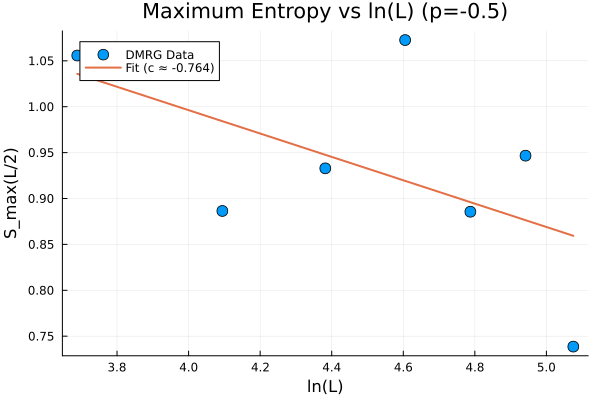

In [29]:
p_fixed = -0.5
lambda = 1.0

N_values = [40, 60, 80, 100, 120, 140, 160]
max_entropies = Float64[]

sweeps = Sweeps(10)
maxdim!(sweeps, 10, 20, 100, 200, 400)
cutoff!(sweeps, 1e-10)
noise!(sweeps, 1e-4, 1e-5, 1e-6, 0.0)


@showprogress for N in N_values
    sites = siteinds("S=1/2", N)
    
    H = build_alcaraz_H(sites, lambda, p_fixed)
    
    psi0 = randomMPS(sites, 10)
    energy, psi = dmrg(H, psi0, sweeps; outputlevel=0)
    
    # entropy at the exact middle of the chain (b = N/2)
    mid_bond = div(N, 2)
    orthogonalize!(psi, mid_bond)
    
    _, S, _ = svd(psi[mid_bond], (linkind(psi, mid_bond-1), siteind(psi, mid_bond)))
    
    SvN_mid = 0.0
    for n in 1:dim(S, 1)
        prob = S[n,n]^2
        if prob > 1e-12
            SvN_mid -= prob * log(prob)
        end
    end
    
    push!(max_entropies, SvN_mid)
end


# Our X axis is ln(N)
x_values = log.(N_values)
y_values = max_entropies

# Linear fit: S_max = (c/6) * ln(N) + k'
@. model(x, p) = p[1]*x + p[2]
p0 = [0.1, 1.0] 

fit = curve_fit(model, x_values, y_values, p0)

slope = fit.param[1]
c_est = slope * 6.0 


println("Estimated Central Charge (c): $(round(c_est, digits=3))")

# Ploting
fig = plot(title="Maximum Entropy vs ln(L) (p=$p_fixed)",
           xlabel="ln(L)",
           ylabel="S_max(L/2)",
           legend=:topleft,
           grid=true)

scatter!(fig, x_values, y_values, label="DMRG Data", markersize=6)

y_fit = model(x_values, fit.param)
plot!(fig, x_values, y_fit, label="Fit (c ≈ $(round(c_est, digits=3)))", linewidth=2)

display(fig)

---

Progress: 100%|█████████████████████████████████████████| Time: 0:02:23


Estimated Central Charge (c): 0.508


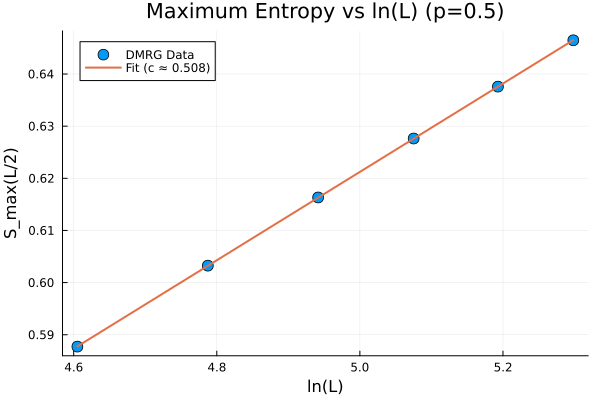

In [12]:
p_fixed = 0.5
lambda = 1.0

N_values = [100, 120, 140, 160, 180, 200]
max_entropies = Float64[]

sweeps = Sweeps(15)
maxdim!(sweeps, 10, 20, 100, 200, 400, 800, 1000, 1200)
cutoff!(sweeps, 1e-12)
noise!(sweeps, 1e-4, 1e-5, 1e-6, 0.0)


@showprogress for N in N_values
    sites = siteinds("S=1/2", N)
    
    H = build_alcaraz_H(sites, lambda, p_fixed)
    
    psi0 = randomMPS(sites, 10)
    energy, psi = dmrg(H, psi0, sweeps; outputlevel=0)
    
    # entropy at the exact middle of the chain (b = N/2)
    mid_bond = div(N, 2)
    orthogonalize!(psi, mid_bond)
    
    _, S, _ = svd(psi[mid_bond], (linkind(psi, mid_bond-1), siteind(psi, mid_bond)))
    
    SvN_mid = 0.0
    for n in 1:dim(S, 1)
        prob = S[n,n]^2
        if prob > 0
            SvN_mid -= prob * log(prob)
        end
    end
    
    push!(max_entropies, SvN_mid)
end


# Our X axis is ln(N)
x_values = log.(N_values)
y_values = max_entropies

# Linear fit: S_max = (c/6) * ln(N) + k'
@. model(x, p) = p[1]*x + p[2]
p0 = [0.1, 1.0] 

fit = curve_fit(model, x_values, y_values, p0)

slope = fit.param[1]
c_est = slope * 6.0 


println("Estimated Central Charge (c): $(round(c_est, digits=3))")

# Ploting
fig = plot(title="Maximum Entropy vs ln(L) (p=$p_fixed)",
           xlabel="ln(L)",
           ylabel="S_max(L/2)",
           legend=:topleft,
           grid=true)

scatter!(fig, x_values, y_values, label="DMRG Data", markersize=6)

y_fit = model(x_values, fit.param)
plot!(fig, x_values, y_fit, label="Fit (c ≈ $(round(c_est, digits=3)))", linewidth=2)

display(fig)
# savefig(fig, "./imgs/cft_L.png")

Progress: 100%|█████████████████████████████████████████| Time: 0:01:36


Estimated Central Charge (c): 0.493


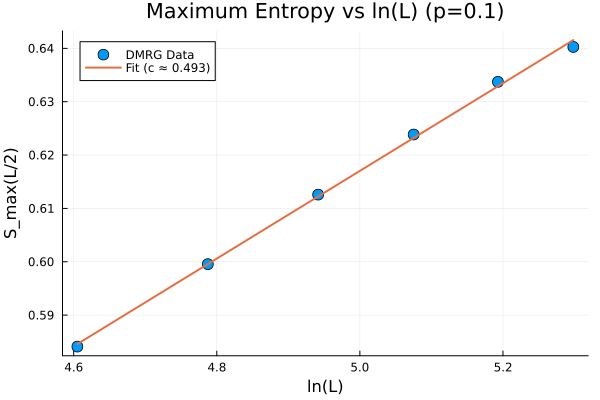

In [14]:
p_fixed = 0.1
lambda = 1.0

N_values = [100, 120, 140, 160, 180, 200]
max_entropies = Float64[]

sweeps = Sweeps(15)
maxdim!(sweeps, 10, 20, 100, 200, 400, 800, 1000, 1200)
cutoff!(sweeps, 1e-12)
noise!(sweeps, 1e-4, 1e-5, 1e-6, 0.0)


@showprogress for N in N_values
    sites = siteinds("S=1/2", N)
    
    H = build_alcaraz_H(sites, lambda, p_fixed)
    
    psi0 = randomMPS(sites, 10)
    energy, psi = dmrg(H, psi0, sweeps; outputlevel=0)
    
    # entropy at the exact middle of the chain (b = N/2)
    mid_bond = div(N, 2)
    orthogonalize!(psi, mid_bond)
    
    _, S, _ = svd(psi[mid_bond], (linkind(psi, mid_bond-1), siteind(psi, mid_bond)))
    
    SvN_mid = 0.0
    for n in 1:dim(S, 1)
        prob = S[n,n]^2
        if prob > 0
            SvN_mid -= prob * log(prob)
        end
    end
    
    push!(max_entropies, SvN_mid)
end


# Our X axis is ln(N)
x_values = log.(N_values)
y_values = max_entropies

# Linear fit: S_max = (c/6) * ln(N) + k'
@. model(x, p) = p[1]*x + p[2]
p0 = [0.1, 1.0] 

fit = curve_fit(model, x_values, y_values, p0)

slope = fit.param[1]
c_est = slope * 6.0 


println("Estimated Central Charge (c): $(round(c_est, digits=3))")

# Ploting
fig = plot(title="Maximum Entropy vs ln(L) (p=$p_fixed)",
           xlabel="ln(L)",
           ylabel="S_max(L/2)",
           legend=:topleft,
           grid=true)

scatter!(fig, x_values, y_values, label="DMRG Data", markersize=6)

y_fit = model(x_values, fit.param)
plot!(fig, x_values, y_fit, label="Fit (c ≈ $(round(c_est, digits=3)))", linewidth=2)

display(fig)
# savefig(fig, "./imgs/cft_L.png")

Progress: 100%|█████████████████████████████████████████| Time: 0:03:32


Estimated Central Charge (c): 0.507


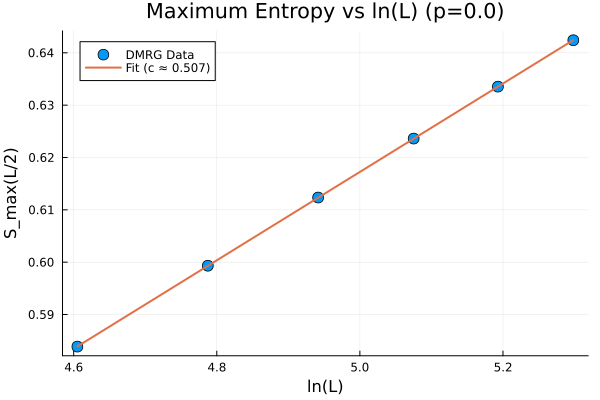

In [22]:
p_fixed = 0.0
lambda = 1.0

N_values = [100, 120, 140, 160, 180, 200]
max_entropies = Float64[]

sweeps = Sweeps(50)
maxdim!(sweeps, 10, 20, 100, 200, 400, 800, 1000, 1200)
cutoff!(sweeps, 1e-12)
noise!(sweeps, 1e-4, 1e-5, 1e-6, 0.0)


@showprogress for N in N_values
    sites = siteinds("S=1/2", N)
    
    H = build_alcaraz_H(sites, lambda, p_fixed)
    
    psi0 = randomMPS(sites, 10)
    energy, psi = dmrg(H, psi0, sweeps; outputlevel=0)
    
    # entropy at the exact middle of the chain (b = N/2)
    mid_bond = div(N, 2)
    orthogonalize!(psi, mid_bond)
    
    _, S, _ = svd(psi[mid_bond], (linkind(psi, mid_bond-1), siteind(psi, mid_bond)))
    
    SvN_mid = 0.0
    for n in 1:dim(S, 1)
        prob = S[n,n]^2
        if prob > 0
            SvN_mid -= prob * log(prob)
        end
    end
    
    push!(max_entropies, SvN_mid)
end


# Our X axis is ln(N)
x_values = log.(N_values)
y_values = max_entropies

# Linear fit: S_max = (c/6) * ln(N) + k'
@. model(x, p) = p[1]*x + p[2]
p0 = [0.1, 1.0] 

fit = curve_fit(model, x_values, y_values, p0)

slope = fit.param[1]
c_est = slope * 6.0 


println("Estimated Central Charge (c): $(round(c_est, digits=3))")

# Ploting
fig = plot(title="Maximum Entropy vs ln(L) (p=$p_fixed)",
           xlabel="ln(L)",
           ylabel="S_max(L/2)",
           legend=:topleft,
           grid=true)

scatter!(fig, x_values, y_values, label="DMRG Data", markersize=6)

y_fit = model(x_values, fit.param)
plot!(fig, x_values, y_fit, label="Fit (c ≈ $(round(c_est, digits=3)))", linewidth=2)

display(fig)
# savefig(fig, "./imgs/cft_L.png")

The CFT prediction for the entanglement entropy of a block of size $x$ in a finite chain of length $L$ with OBC is governed by the chord distance:$$S(x) = \frac{c}{6} \ln \left( \frac{2L}{\pi} \sin\left(\frac{\pi x}{L}\right) \right) + g$$

Running DMRG...
After sweep 1 energy=-180.6772526075925  maxlinkdim=20 maxerr=1.20E-04 time=0.313
After sweep 2 energy=-180.7944788570948  maxlinkdim=83 maxerr=9.99E-13 time=1.801
After sweep 3 energy=-180.8131671231401  maxlinkdim=75 maxerr=1.00E-12 time=2.714
After sweep 4 energy=-180.82375608603604  maxlinkdim=60 maxerr=9.97E-13 time=1.340
After sweep 5 energy=-180.82727351457896  maxlinkdim=55 maxerr=9.96E-13 time=1.593
After sweep 6 energy=-180.82846003001742  maxlinkdim=64 maxerr=9.98E-13 time=1.791
After sweep 7 energy=-180.82860140928528  maxlinkdim=60 maxerr=9.99E-13 time=1.247
After sweep 8 energy=-180.82860771442157  maxlinkdim=52 maxerr=1.00E-12 time=1.582
After sweep 9 energy=-180.82860780312464  maxlinkdim=44 maxerr=1.00E-12 time=0.832
After sweep 10 energy=-180.82860780307905  maxlinkdim=43 maxerr=9.96E-13 time=0.807
After sweep 11 energy=-180.82860780307792  maxlinkdim=43 maxerr=9.91E-13 time=1.287
After sweep 12 energy=-180.8286078030777  maxlinkdim=43 maxerr=9.85E-13 

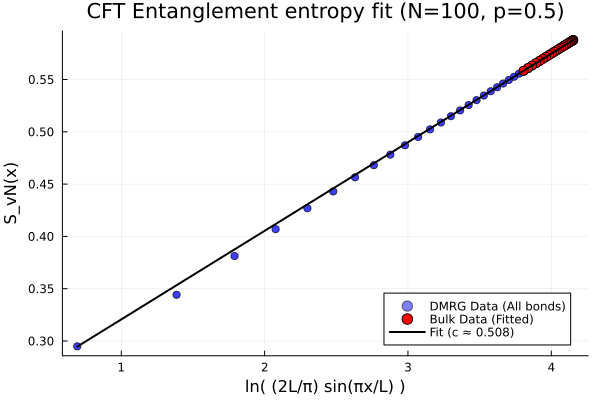

In [23]:
N = 100
lambda = 1.0
p_fixed = 0.5

sites = siteinds("S=1/2", N)


H = build_alcaraz_H(sites, lambda, p_fixed)

# DMRG
sweeps = Sweeps(50)
maxdim!(sweeps, 20, 100, 200, 400, 800, 1000)
cutoff!(sweeps, 1e-12)
noise!(sweeps, 1e-4, 1e-5, 1e-6, 0.0)

psi0 = randomMPS(sites, 10)
println("Running DMRG...")
energy, psi = dmrg(H, psi0, sweeps; outputlevel=1)

# Spatial Entanglement Sweep
entropies = Float64[]
bonds = collect(1:(N-1))

println("Calculating Entanglement Entropy across all spatial cuts...")
for b in bonds
    orthogonalize!(psi, b)
    
    # Handle the OBC edge case: no left link for the first site
    if b == 1
        left_inds = (siteind(psi, b),)
    else
        left_inds = (linkind(psi, b-1), siteind(psi, b))
    end
    
    _, S, _ = svd(psi[b], left_inds)
    
    SvN = 0.0
    for n in 1:dim(S, 1)
        prob = S[n,n]^2
        if prob > 0.0
            SvN -= prob * log(prob)
        end
    end
    
    push!(entropies, SvN)
end

# Fit
chord_distances = @. (2 * N / pi) * sin(pi * bonds / N)
x_values = log.(chord_distances)
y_values = entropies


bulk_indices = findall(x -> (N/4 <= x <= 3N/4), bonds)
x_fit_data = x_values[bulk_indices]
y_fit_data = y_values[bulk_indices]

# Model: y = (c/6) * x + g -> param[1] is c, param[2] is g
@. model(x, p) = (p[1]/6.0) * x + p[2]
p0 = [0.5, 1.0] # Initial guess expecting c=0.5

fit = curve_fit(model, x_fit_data, y_fit_data, p0)
c_est = fit.param[1]

println("Estimated Central Charge (c): $(round(c_est, digits=4))")

# --- 6. Plotting ---
fig = plot(title="CFT Entanglement entropy fit (N=$N, p=$p_fixed)",
           xlabel="ln( (2L/π) sin(πx/L) )",
           ylabel="S_vN(x)",
           legend=:bottomright,
           grid=true)

scatter!(fig, x_values, y_values, label="DMRG Data (All bonds)", markersize=4, color=:blue, alpha=0.5)

scatter!(fig, x_fit_data, y_fit_data, label="Bulk Data (Fitted)", markersize=5, color=:red)

# Plot the ideal fit line extended across the graph
x_line = range(minimum(x_values), maximum(x_values), length=100)
y_line = model(x_line, fit.param)
plot!(fig, x_line, y_line, label="Fit (c ≈ $(round(c_est, digits=3)))", linewidth=2, color=:black)

display(fig)

Running DMRG...
After sweep 1 energy=-126.60016433955892  maxlinkdim=20 maxerr=7.89E-05 time=0.226
After sweep 2 energy=-126.8915936389726  maxlinkdim=76 maxerr=1.00E-12 time=0.726
After sweep 3 energy=-126.94003230440647  maxlinkdim=76 maxerr=9.99E-13 time=1.729
After sweep 4 energy=-126.94872306682002  maxlinkdim=49 maxerr=9.98E-13 time=0.877
After sweep 5 energy=-126.95149323602375  maxlinkdim=43 maxerr=1.00E-12 time=0.682
After sweep 6 energy=-126.9534924756923  maxlinkdim=40 maxerr=9.95E-13 time=1.029
After sweep 7 energy=-126.95550629423845  maxlinkdim=39 maxerr=9.94E-13 time=0.398
After sweep 8 energy=-126.95768521895921  maxlinkdim=38 maxerr=9.97E-13 time=0.396
After sweep 9 energy=-126.95969415725158  maxlinkdim=47 maxerr=9.86E-13 time=0.372
After sweep 10 energy=-126.96102043780206  maxlinkdim=55 maxerr=9.98E-13 time=0.468
After sweep 11 energy=-126.96156329712812  maxlinkdim=55 maxerr=9.97E-13 time=0.491
After sweep 12 energy=-126.96177495729769  maxlinkdim=44 maxerr=9.95E-1

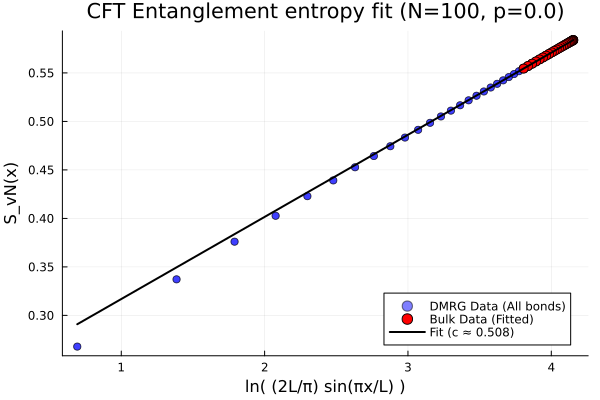

In [24]:
N = 100
lambda = 1.0
p_fixed = 0.0

sites = siteinds("S=1/2", N)


H = build_alcaraz_H(sites, lambda, p_fixed)

# DMRG
sweeps = Sweeps(50)
maxdim!(sweeps, 20, 100, 200, 400, 800, 1000)
cutoff!(sweeps, 1e-12)
noise!(sweeps, 1e-4, 1e-5, 1e-6, 0.0)

psi0 = randomMPS(sites, 10)
println("Running DMRG...")
energy, psi = dmrg(H, psi0, sweeps; outputlevel=1)

# Spatial Entanglement Sweep
entropies = Float64[]
bonds = collect(1:(N-1))

println("Calculating Entanglement Entropy across all spatial cuts...")
for b in bonds
    orthogonalize!(psi, b)
    
    # Handle the OBC edge case: no left link for the first site
    if b == 1
        left_inds = (siteind(psi, b),)
    else
        left_inds = (linkind(psi, b-1), siteind(psi, b))
    end
    
    _, S, _ = svd(psi[b], left_inds)
    
    SvN = 0.0
    for n in 1:dim(S, 1)
        prob = S[n,n]^2
        if prob > 0.0
            SvN -= prob * log(prob)
        end
    end
    
    push!(entropies, SvN)
end

# Fit
chord_distances = @. (2 * N / pi) * sin(pi * bonds / N)
x_values = log.(chord_distances)
y_values = entropies


bulk_indices = findall(x -> (N/4 <= x <= 3N/4), bonds)
x_fit_data = x_values[bulk_indices]
y_fit_data = y_values[bulk_indices]

# Model: y = (c/6) * x + g -> param[1] is c, param[2] is g
@. model(x, p) = (p[1]/6.0) * x + p[2]
p0 = [0.5, 1.0] # Initial guess expecting c=0.5

fit = curve_fit(model, x_fit_data, y_fit_data, p0)
c_est = fit.param[1]

println("Estimated Central Charge (c): $(round(c_est, digits=4))")

# --- 6. Plotting ---
fig = plot(title="CFT Entanglement entropy fit (N=$N, p=$p_fixed)",
           xlabel="ln( (2L/π) sin(πx/L) )",
           ylabel="S_vN(x)",
           legend=:bottomright,
           grid=true)

scatter!(fig, x_values, y_values, label="DMRG Data (All bonds)", markersize=4, color=:blue, alpha=0.5)

scatter!(fig, x_fit_data, y_fit_data, label="Bulk Data (Fitted)", markersize=5, color=:red)

# Plot the ideal fit line extended across the graph
x_line = range(minimum(x_values), maximum(x_values), length=100)
y_line = model(x_line, fit.param)
plot!(fig, x_line, y_line, label="Fit (c ≈ $(round(c_est, digits=3)))", linewidth=2, color=:black)

display(fig)